# Fraud Detection Model Evaluation

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
os.makedirs("docs", exist_ok=True)
os.chdir("C:/Users/shali/azure-fraud-detection")
sys.path.insert(0, "C:/Users/shali/azure-fraud-detection")
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve
plt.style.use("seaborn-v0_8-whitegrid")
print(f"Working dir: {os.getcwd()}")
print("Imports OK")


Working dir: C:\Users\shali\azure-fraud-detection
Imports OK


In [2]:
model = joblib.load("ml_training/models/model.joblib")
preprocessor = joblib.load("ml_training/models/preprocessor.joblib")
from ml_training.fraud_detection.config import DATA_PATH, NUMERICAL_FEATURES, TARGET_COLUMN
df = pd.read_csv(DATA_PATH)
from ml_training.fraud_detection.data_preparation import prepare_data
X_train, X_test, y_train, y_test = prepare_data(df)
X_test_scaled = preprocessor.transform(X_test)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)
print(f"Test samples: {len(y_test)}")
print(f"Fraud cases: {y_test.sum()}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_pred_proba):.4f}")


Train size: 227845, Test size: 56962
Train fraud count: 394, Test fraud count: 98
Test samples: 56962
Fraud cases: 98
AUC-ROC: 0.9733
Avg Precision: 0.8741


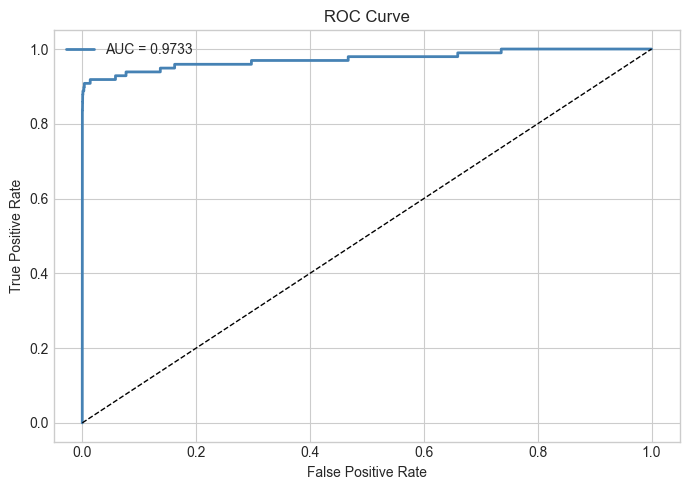

Saved roc_curve.png


In [3]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig("docs/roc_curve.png", dpi=120)
plt.show()
print("Saved roc_curve.png")


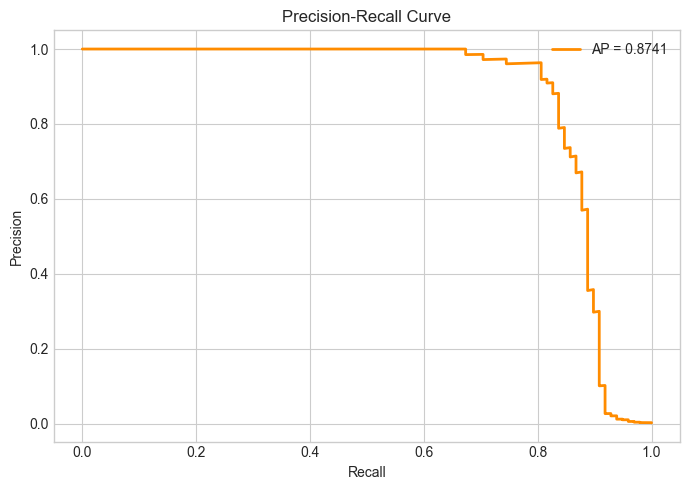

Saved precision_recall_curve.png


In [4]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color="darkorange", lw=2, label=f"AP = {ap:.4f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.savefig("docs/precision_recall_curve.png", dpi=120)
plt.show()
print("Saved precision_recall_curve.png")


Optimal threshold: 0.9101
Precision: 0.9634, Recall: 0.8061, F1: 0.8778


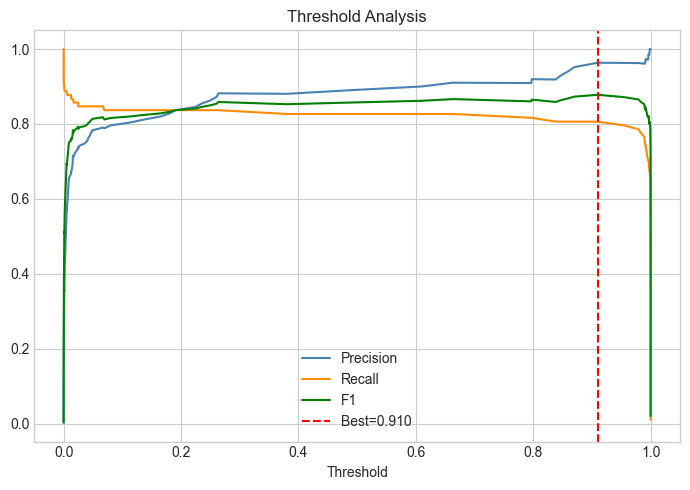

Saved threshold_analysis.png


In [5]:
f1_scores = 2*(precision[:-1]*recall[:-1])/(precision[:-1]+recall[:-1]+1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}, Recall: {recall[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}")
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, precision[:-1], label="Precision", color="steelblue")
ax.plot(thresholds, recall[:-1], label="Recall", color="darkorange")
ax.plot(thresholds, f1_scores, label="F1", color="green")
ax.axvline(best_threshold, color="red", linestyle="--", label=f"Best={best_threshold:.3f}")
ax.set_xlabel("Threshold")
ax.set_title("Threshold Analysis")
ax.legend()
plt.tight_layout()
plt.savefig("docs/threshold_analysis.png", dpi=120)
plt.show()
print("Saved threshold_analysis.png")


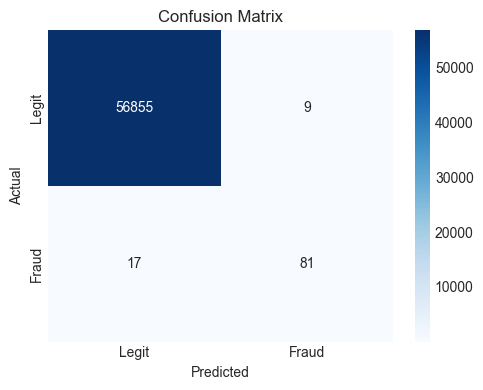

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [6]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit","Fraud"],
            yticklabels=["Legit","Fraud"], ax=ax)
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.savefig("docs/confusion_matrix.png", dpi=120)
plt.show()
print(classification_report(y_test, y_pred, target_names=["Legit","Fraud"]))


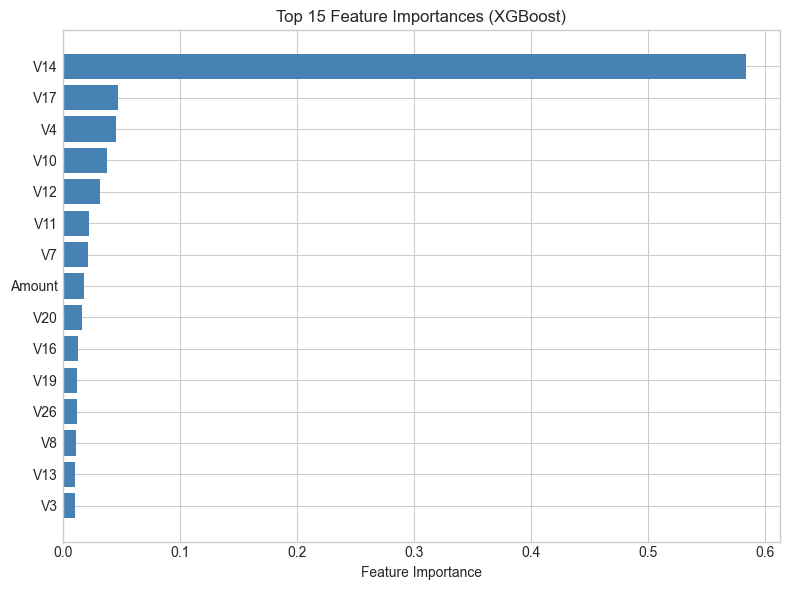

Saved feature_importance.png


In [7]:
importance = model.feature_importances_
feat_df = pd.DataFrame({"feature": NUMERICAL_FEATURES, "importance": importance})
feat_df = feat_df.sort_values("importance", ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(feat_df["feature"], feat_df["importance"], color="steelblue")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.savefig("docs/feature_importance.png", dpi=120)
plt.show()
print("Saved feature_importance.png")


In [8]:
print("=== Summary ===")
print(f"AUC-ROC:           {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"Optimal Threshold: {best_threshold:.4f}")
cm2 = confusion_matrix(y_test, y_pred)
print(f"True Positives:  {cm2[1][1]}")
print(f"False Positives: {cm2[0][1]}")
print(f"False Negatives: {cm2[1][0]}")
print(f"True Negatives:  {cm2[0][0]}")


=== Summary ===
AUC-ROC:           0.9733
Average Precision: 0.8741
Optimal Threshold: 0.9101
True Positives:  81
False Positives: 9
False Negatives: 17
True Negatives:  56855
